# **Text Mining Project 2025/26**

1. ✅ Data Exploration        ← já fizemos
2. 🔄 Data Preprocessing     ← próximo passo
3.    Corpus Split            ← train/validation
4.    Feature Engineering     ← BoW, Word2Vec, Transformers
5.    Classification Models   ← ML clássico + Transformers
6.    Avaliação & Análise     ← métricas e conclusões
7.    Predições no test.csv   ← ficheiro pred_xx.csv final 

<b><h3> Group 40</h3></b>

<table>
  <thead style="color:#d9c8a3;">
    <tr>
      <th>Name</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Rodrigo Santos</td>
      <td>20250387</td>
    </tr>
    <tr>
      <td>Mónica Shaskin</td>
      <td>20250392</td>
    </tr>
    <tr>
      <td>Nadia Scaletchi</td>
      <td>20250404</td>
    </tr>
    <tr>
      <td>Rodrigo Teixeira</td>
      <td>20250393</td>
    </tr>
  </tbody>
</table> 

## **Table of Contents**

# **1. Introduction**

# **2. Enviroment Setup and Data Loading**

### **Library Installation**

In [27]:
!pip install nltk
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Imports**

In [28]:
# Standard Libraries
import re
import string
import warnings
from collections import Counter
from itertools import combinations

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

### **Settings and NLP Resources**

In [29]:
warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

STOP = set(stopwords.words("english"))

### **Class Labels and Visualization Colors**

In [30]:
# Palette consistent with the three classes
CLASS_COLORS = {
    0: "#e74c3c",
    1: "#2ecc71",
    2: "#3498db"
}

CLASS_NAMES = {
    0: "Bearish (0)",
    1: "Bullish (1)",
    2: "Neutral (2)"
}

### **Load Training Dataset**

In [31]:
df = pd.read_csv('train.csv')  

# **3. Exploratory Data Analysis**

This section explores the structure and main characteristics of the training corpus before applying preprocessing and modelling techniques.

### **Dataset Overview**

This first step provides a general overview of the dataset, including its dimensions, variables, data types, missing values, and initial observations.

In [32]:
# Print the dimensions of the DataFrame (rows, columns)
print(f'Shape: {df.shape}')

# Print the list of column names
print(f'Columns: {list(df.columns)}')

# Print the data type of each column
print(f'Types:\n{df.dtypes}')

# Print the count of missing (NaN) values per column
print(f'\nMissing values:\n{df.isnull().sum()}')

# Display the first 10 rows of the DataFrame
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']
Types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


### **Duplicate Analysis**

This step checks whether the training dataset contains duplicated tweets or tweets that appear multiple times with different sentiment labels.

In [33]:
# Count rows with duplicate text (regardless of label)
exact_duplicates = df.duplicated(subset='text').sum()
# Count rows with duplicate text AND label
label_duplicates = df.duplicated(subset=['text', 'label']).sum()

print(f'Duplicate tweets (same text): {exact_duplicates}')
print(f'Duplicate tweets (same text + label): {label_duplicates}')

# Show duplicate examples if any exist
if exact_duplicates > 0:
    mask = df.duplicated(subset='text', keep=False)
    print(f'\nDuplicate tweet examples:')
    print(df[mask][['text','label']].sort_values('text').head(10).to_string())
    
    # Edge case: same tweet with conflicting labels — dangerous for training!
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]  # Keep only texts with more than one distinct label
    print(f'\nTweets with conflicting labels (same text, different label): {len(conflicts)}')
    if len(conflicts) > 0:
        # Show the conflicting rows
        print(df[df['text'].isin(conflicts.index)][['text','label']].sort_values('text').head(10).to_string())

Duplicate tweets (same text): 0
Duplicate tweets (same text + label): 0


### **Class Distribution**

This analysis examines the distribution of the three sentiment classes and helps identify possible class imbalance in the dataset. If one class dominates the corpus, for example if most tweets are labeled as Neutral, the models may become biased toward predicting that class more frequently, which can negatively affect performance on the minority classes.

=== Class count ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


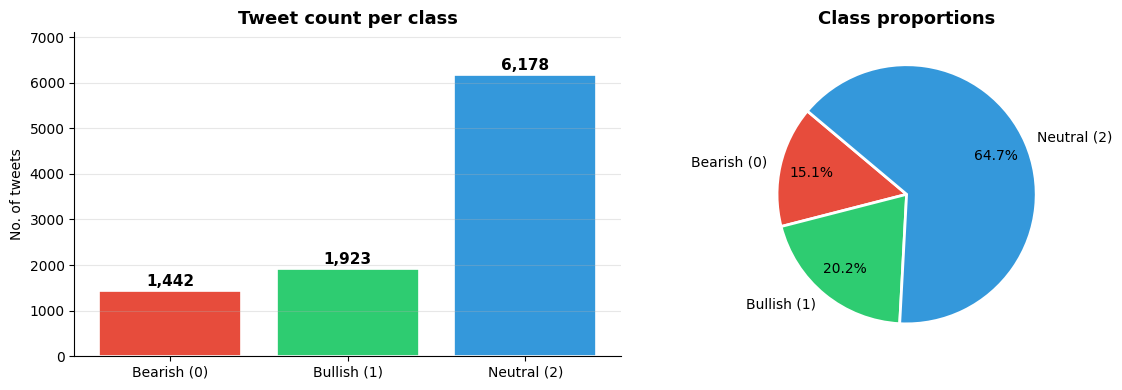


Baseline (majority class): 64.7% — any model should beat this value.


In [34]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== Class count ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — count per class with value labels on top
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No. of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart — class proportions
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

# Majority class baseline: accuracy of a model that always predicts the most frequent class.
# Any trained model must beat this, otherwise it has learned nothing useful.
majority_acc = label_counts.max() / len(df) * 100
print(f'\nBaseline (majority class): {majority_acc:.1f}% — any model should beat this value.')

### **Example Tweets by Class**

This section displays examples of tweets from each sentiment class to better understand the type of language associated with Bearish, Bullish, and Neutral labels

In [35]:
# Show 3 random examples from each class
for lbl in [0, 1, 2]: 
    print(f"\n{CLASS_NAMES[lbl]}") 
    display(df[df["label"] == lbl][["text", "label"]].sample(3, random_state=42)) #random_state=42 fixes the random sampling so the results are the same every time we run the notebook


Bearish (0)


,text,label
2985,Why These Top Oil Stocks All Tumbled More Than...,0
3656,Turkish lira weakens past key 6-per-dollar level,0
3333,Norsk Hydro reports lower Q4 earnings on weak ...,0



Bullish (1)


,text,label
7823,$CHFS big buyers here. Might bounce before the...,1
9175,$FIZZ - National Beverage +4% as analysts keep...,1
3451,Genpact beat estimates in Q4,1



Neutral (2)


,text,label
3925,(Free to read) Over 60% of Americans say that ...,2
4186,"Best Buy has dodged death, but for how long? W...",2
8600,How Good Is CENTROTEC Sustainable AG (ETR:CEV)...,2


### **Tweet Length Analysis**

This analysis examines tweet length using the number of characters, words, and tokens across the different sentiment classes.

=== Length statistics (chars / words) ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.9     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


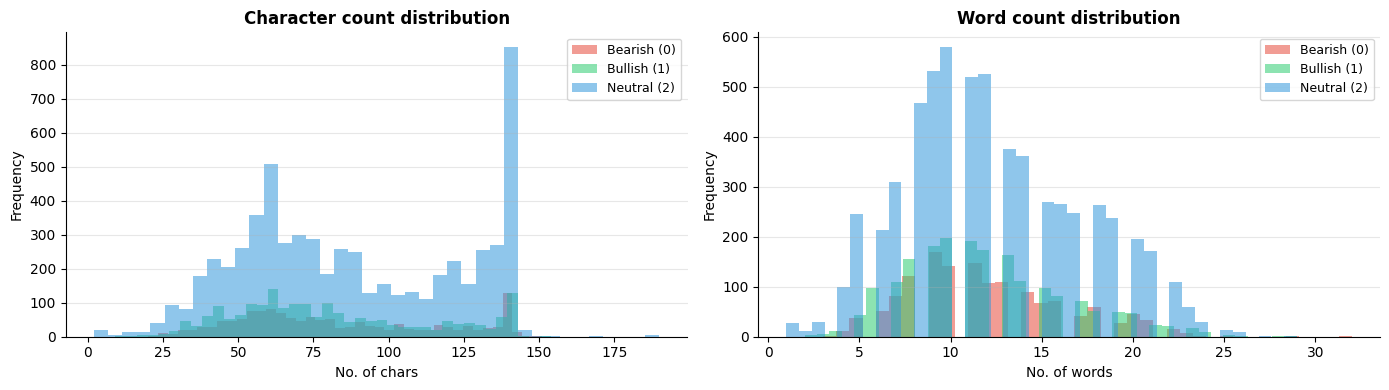


=== Average length per class ===
             n_chars  n_words
label                        
Bearish (0)     83.4     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [36]:
# Compute length features for each tweet
df['n_chars']  = df['text'].str.len()                                # number of characters
df['n_words']  = df['text'].str.split().str.len()                    # number of whitespace-split words
df['n_tokens'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))  # number of NLTK tokens

print('=== Length statistics (chars / words) ===')
print(df[['n_chars', 'n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot character and word count distributions, one histogram per class
for metric, ax, title in [
    ('n_chars', axes[0], 'Character count distribution'),
    ('n_words', axes[1], 'Word count distribution')
]:
    for lbl in [0, 1, 2]:
        subset = df[df['label'] == lbl][metric]
        ax.hist(subset, bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric.replace('n_', 'No. of '))
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_length_distribution.png', bbox_inches='tight')
plt.show()

# Average length broken down by class
print('\n=== Average length per class ===')
print(df.groupby('label')[['n_chars', 'n_words']].mean().round(1).rename(index=CLASS_NAMES))

### **Vocabulary Analysis**

A simple exploratory cleaning function is used to analyze the most frequent words in the dataset without URLs, mentions, punctuation, or stopwords.

In [37]:
def tokenize_clean(text):
    """Tokenizes, lowercases, removes punctuation and stopwords."""
    text  = str(text).lower()
    text  = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text  = re.sub(r'@\w+|#\w+', '', text)            # remove @mentions and #hashtags
    text  = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

# Build a flat list of all tokens across every tweet
all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_clean(txt))

vocab      = set(all_tokens)           # unique words
freq       = Counter(all_tokens)       # word frequencies
top50      = freq.most_common(50)      # top 50 most frequent words

print(f'Total tokens (stopwords removed): {len(all_tokens):,}')
print(f'Unique vocabulary (distinct words): {len(vocab):,}')

# Print the top 20 most frequent words
print(f'\nTop 20 most frequent words:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total tokens (stopwords removed): 73,385
Unique vocabulary (distinct words): 14,016

Top 20 most frequent words:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


### **Most Frequent Words**

This visualization presents the 25 most frequent words in the corpus after a simple exploratory text processing step. For this analysis only, tweets were lowercased and filtered to remove URLs, mentions, hashtags, punctuation, numbers, stopwords, and very short tokens. This allows the most informative words to become more visible in the frequency ranking.

The top 25 words are shown because they provide a broad enough overview of the dominant vocabulary in the corpus without making the chart too crowded or difficult to interpret. Hashtags and financial cashtags are not included here because they are analyzed separately in later sections.

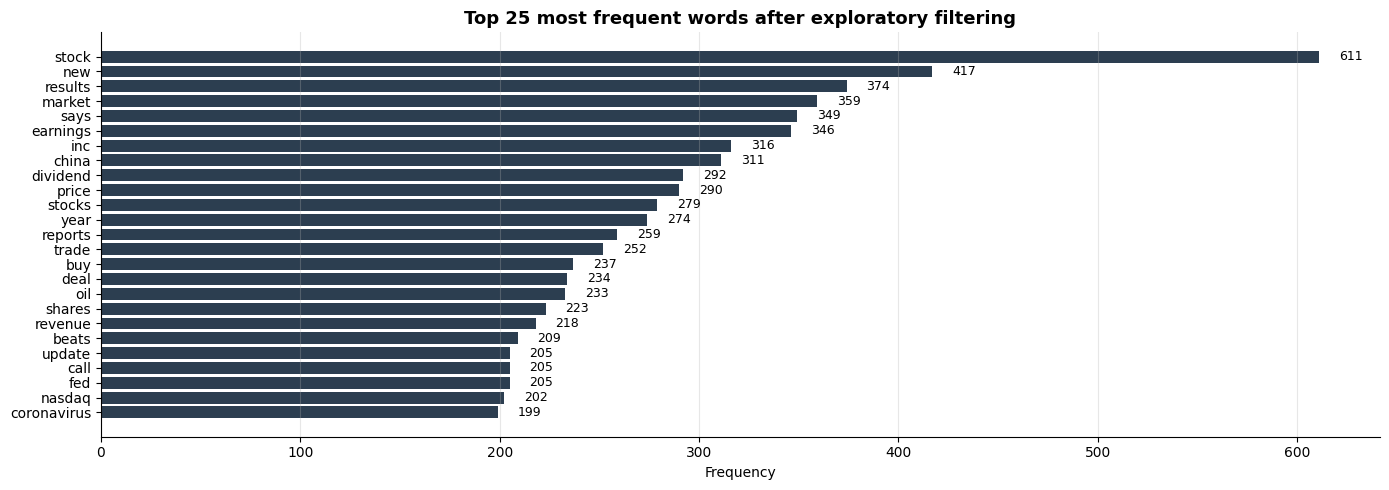

In [38]:
# Unpack the top 25 words and their counts
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))

# Horizontal bar chart (reversed so the most frequent word appears at the top)
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')

# Add frequency labels at the end of each bar
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)

ax.set_title("Top 25 most frequent words after exploratory filtering", fontsize=13, fontweight="bold")
ax.set_xlabel('Frequency')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_top_words.png', bbox_inches='tight')
plt.show()

### **Most Frequent Words by Class**

Using the same exploratory cleaning function defined in the previous section, this analysis examines the most frequent words within each sentiment class. The goal is to identify class-specific vocabulary patterns and better understand which terms are more characteristic of Bearish, Bullish, and Neutral tweets.

To ensure a fair comparison across classes of different sizes, word frequencies are presented as relative frequency per 1000 words rather than as raw counts. The top 20 words are shown for each class, as this provides a clear summary of the most representative terms without making the visualizations too crowded.

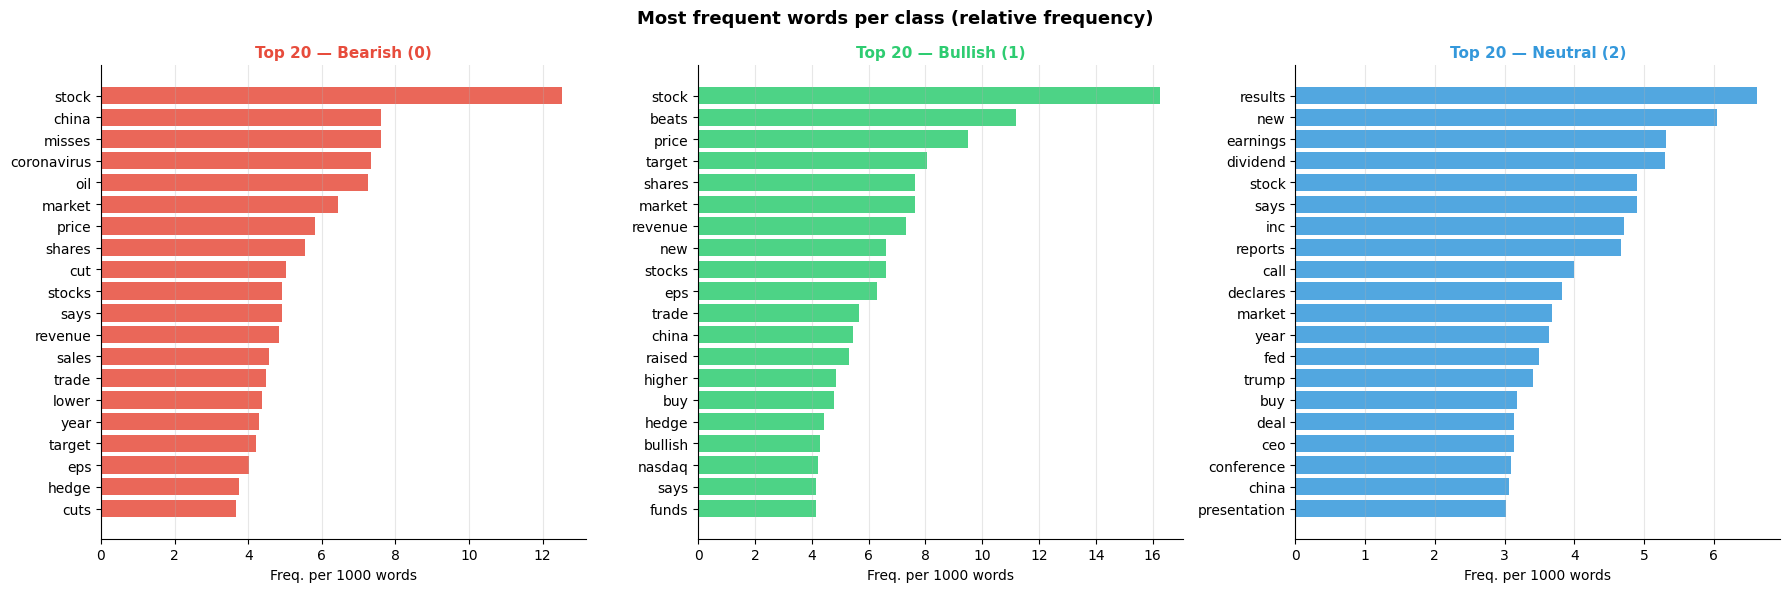

In [39]:
# Build a token counter for each class
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_clean(txt))
    tokens_per_class[lbl] = Counter(toks)

# Total token count per class (used to normalise frequencies)
total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Relative frequency per 1000 words (only words appearing at least 5 times)
    rel_freq = {w: cnt / total_per_class[lbl] * 1000
                for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]
    
    # Horizontal bar chart (reversed so the most frequent word appears at the top)
    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Most frequent words per class (relative frequency)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_words_per_class.png', bbox_inches='tight')
plt.show()

### **Tweet-Specific Features**

In [40]:
# Count special elements in each tweet
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))  # e.g. $AAPL

print('=== Average presence per tweet ===')
for feat in ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets with cashtag ($TICKER): {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')

# Average per class
print('\n=== Average per class ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

=== Average presence per tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets with cashtag ($TICKER): 1,429 (15.0%)

=== Average per class ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


### **Distribution of Tweet-Specific Features by Class**

This visualization compares the distribution of tweet-specific features across the three sentiment classes.

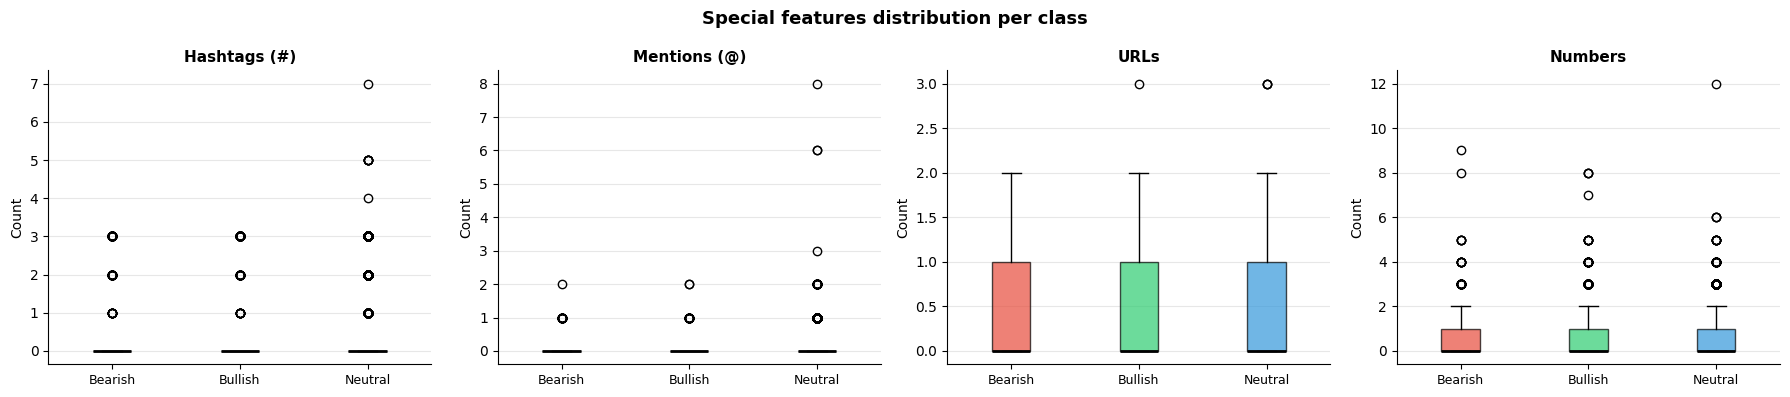

In [41]:
features    = ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']
feat_labels = ['Hashtags (#)', 'Mentions (@)', 'URLs', 'Numbers']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# One boxplot per feature, showing the distribution across the 3 classes
for feat, flabel, ax in zip(features, feat_labels, axes):
    data_by_class = [df[df['label'] == lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    # Color each box by class
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Special features distribution per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_special_features.png', bbox_inches='tight')
plt.show()

### **Hashtags and Cashtags Analysis**

This analysis identifies the most common hashtags and financial cashtags used in the dataset.

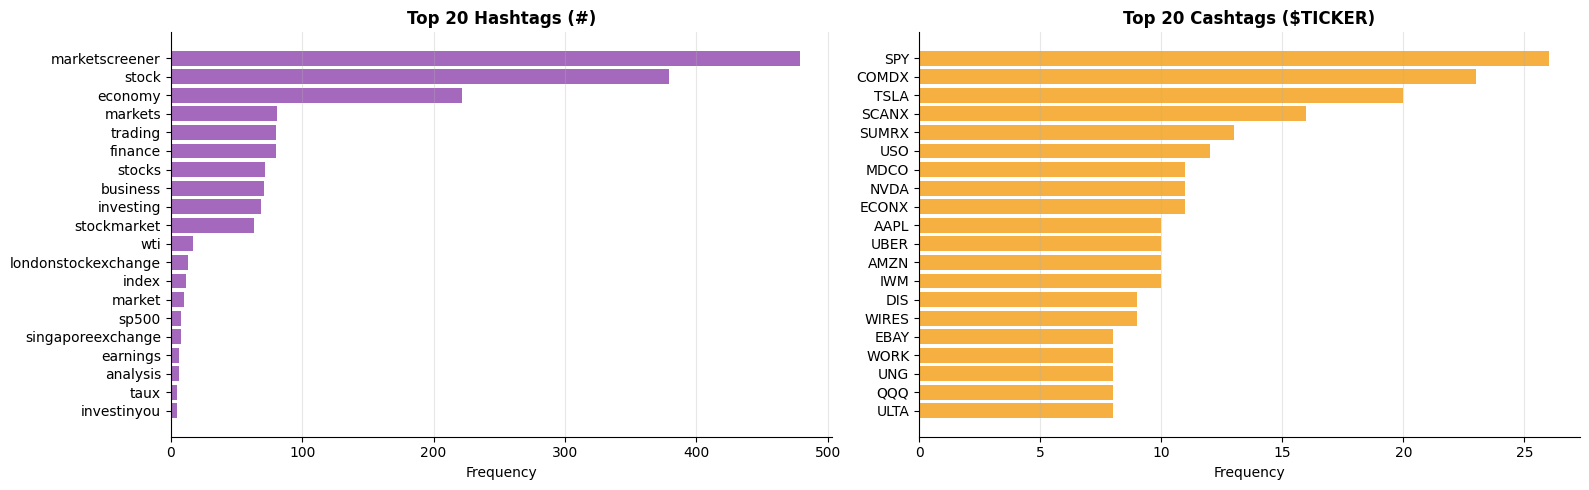

In [42]:
# Collect all hashtags and cashtags across every tweet
all_hashtags = []
for txt in df['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))

top_hashtags = Counter(all_hashtags).most_common(20)

all_cashtags = []
for txt in df['text']:
    all_cashtags.extend(re.findall(r'\$([A-Z]{1,5})', str(txt)))
top_cashtags = Counter(all_cashtags).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hashtag bar chart
if top_hashtags:
    words_h, counts_h = zip(*top_hashtags)
    axes[0].barh(list(reversed(words_h)), list(reversed(counts_h)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequency')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

# Cashtag bar chart (or placeholder if none found)
if top_cashtags:
    words_c, counts_c = zip(*top_cashtags)
    axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
else:
    axes[1].text(0.5, 0.5, 'No cashtags found', ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('fig_hashtags_cashtags.png', bbox_inches='tight')
plt.show()

### **Word Co-occurrence Analysis**

This analysis explores how frequently the most common words appear together in the same tweet, helping identify repeated themes and common financial expressions in the corpus.

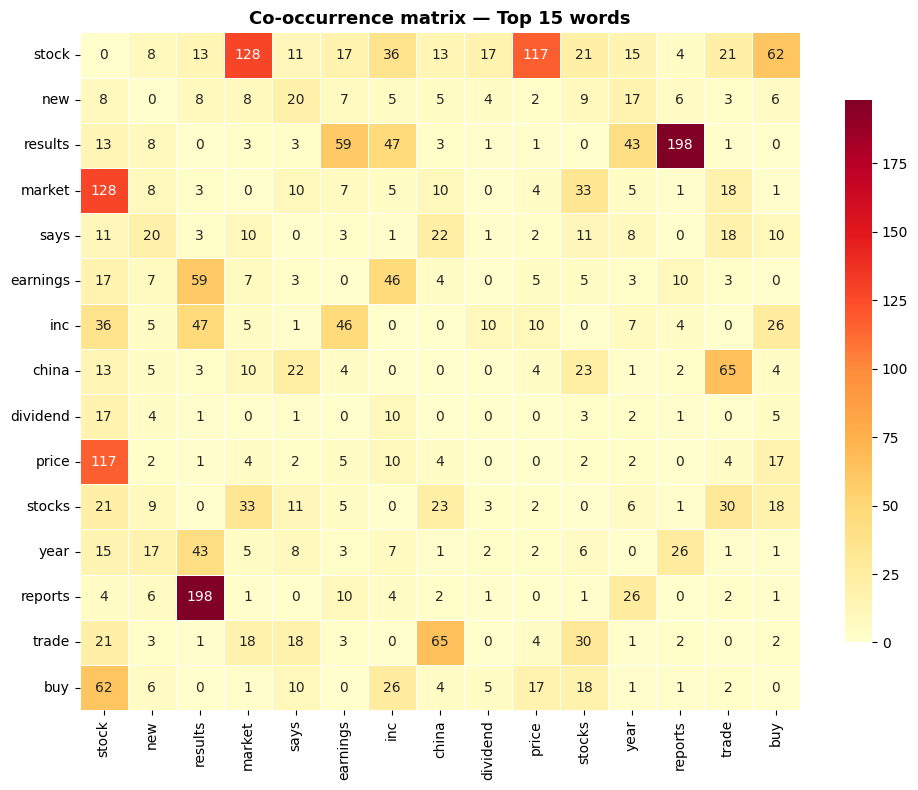

In [43]:
# Build an empty matrix for the 15 most frequent words
top_words_list = [w for w, _ in freq.most_common(15)]
cooc = pd.DataFrame(0, index=top_words_list, columns=top_words_list)

# Count how often each pair of top words appears in the same tweet
for txt in df['text']:
    tokens = set(tokenize_clean(txt)) & set(top_words_list)
    for w1, w2 in combinations(tokens, 2):
        cooc.loc[w1, w2] += 1
        cooc.loc[w2, w1] += 1

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Co-occurrence matrix — Top 15 words', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cooccurrence.png', bbox_inches='tight')
plt.show()

### **Word Clouds by Class**

Using the same exploratory cleaning function from the previous sections, word clouds are generated for each sentiment class. These visualizations provide an intuitive overview of the most prominent words associated with Bearish, Bullish, and Neutral tweets.

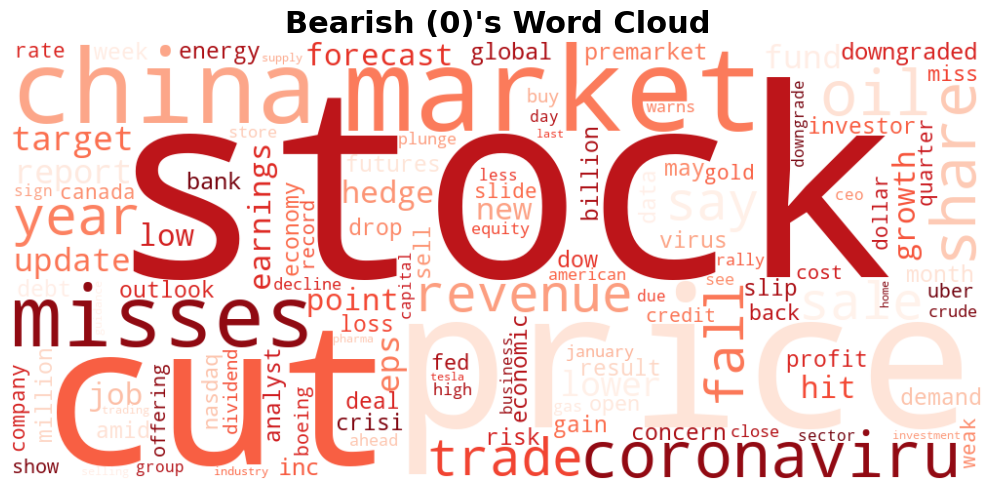

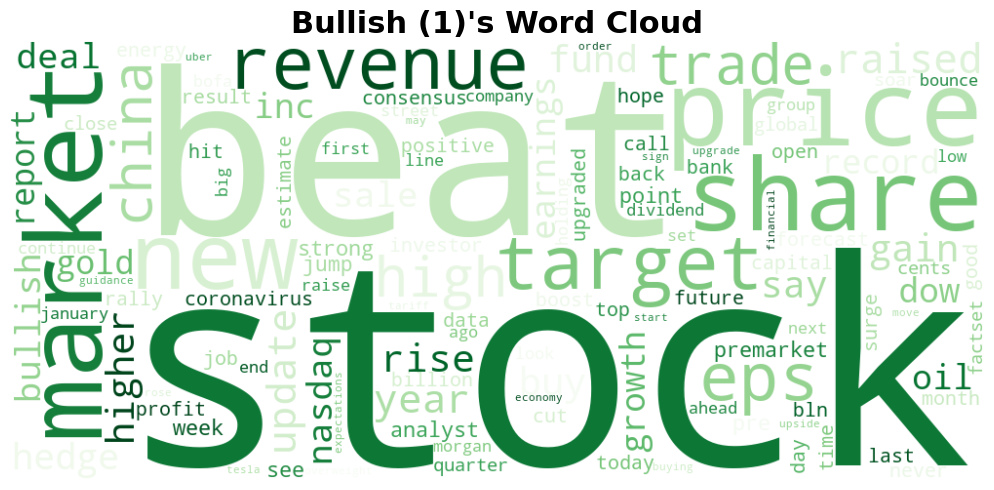

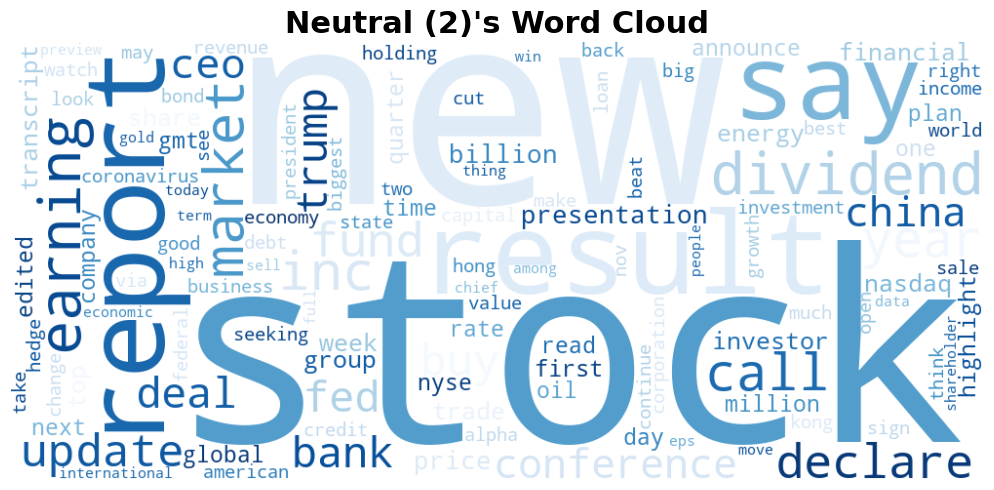

In [44]:
# Create one large word cloud per class
for lbl in [0, 1, 2]:
    class_tokens = []
    
    for txt in df[df["label"] == lbl]["text"]:
        class_tokens.extend(tokenize_clean(txt))
    
    text_for_cloud = " ".join(class_tokens)
    
    wordcloud = WordCloud(
        width=1000,
        height=450,
        background_color="white",
        colormap="Greens" if lbl == 1 else "Reds" if lbl == 0 else "Blues",
        collocations=False,
        max_words=120
    ).generate(text_for_cloud)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{CLASS_NAMES[lbl]}'s Word Cloud", fontsize=22, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig_wordcloud_{lbl}.png", bbox_inches="tight")
    plt.show()

## 9. Resumo e Conclusões

In [45]:
# ── Resumo final ──────────────────────────────────────────────────────────────
print('=' * 60)
print('RESUMO DA DATA EXPLORATION')
print('=' * 60)
print(f'Total de tweets (treino)         : {len(df):,}')
print(f'Vocabulário único (sem stopwords): {len(vocab):,} palavras')
print(f'Total de tokens                  : {len(all_tokens):,}')
print(f'Comprimento médio (palavras)     : {df["n_words"].mean():.1f}')
print(f'Comprimento médio (chars)        : {df["n_chars"].mean():.1f}')
print()
print('Distribuição das classes:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Baseline majority class: {majority_acc:.1f}%')
print()
print('Top 5 palavras mais frequentes:')
for w, c in freq.most_common(5):
    print(f'  {w:<20} {c:>5}')
print('=' * 60)
print()
print('CONCLUSÕES PARA O RELATÓRIO:')
print('- O dataset está [VERIFICAR: balanceado / desbalanceado?].')
print('- Os tweets são curtos (média ~X palavras), típico de Twitter.')
print('- Presença de URLs, hashtags e cashtags exige preprocessing específico.')
print('- As word clouds mostram vocabulário distinto entre classes.')
print('- [ADICIONAR MAIS CONCLUSÕES APÓS VER OS RESULTADOS]')

RESUMO DA DATA EXPLORATION
Total de tweets (treino)         : 9,543
Vocabulário único (sem stopwords): 14,016 palavras
Total de tokens                  : 73,385
Comprimento médio (palavras)     : 12.2
Comprimento médio (chars)        : 85.9

Distribuição das classes:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Baseline majority class: 64.7%

Top 5 palavras mais frequentes:
  stock                  611
  new                    417
  results                374
  market                 359
  says                   349

CONCLUSÕES PARA O RELATÓRIO:
- O dataset está [VERIFICAR: balanceado / desbalanceado?].
- Os tweets são curtos (média ~X palavras), típico de Twitter.
- Presença de URLs, hashtags e cashtags exige preprocessing específico.
- As word clouds mostram vocabulário distinto entre classes.
- [ADICIONAR MAIS CONCLUSÕES APÓS VER OS RESULTADOS]
